In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [18]:
d = pd.read_csv('trajectory_data.csv')
d2 = pd.read_csv('trajectory_data_2.csv')
d3 = pd.read_csv('trajectory_data_3.csv')
d4 = pd.read_csv('trajectory_data_4.csv')

In [19]:
def normalize_height(df, time_col='time', y_col='cy', frame_height=800, distance=10):

    data = df.copy()

    height_raw = frame_height - data[y_col]

    base_y = height_raw.min()
    height_norm = height_raw - base_y

    dips, _ = find_peaks(-height_norm, distance=distance)

    if len(dips) > 1:
        slope, intercept = np.polyfit(data[time_col].iloc[dips], height_norm.iloc[dips], 1)
        data['height_final'] = height_norm - (slope * data[time_col] + intercept)
    else:
        data['height_final'] = height_norm

    return data

def get_first_impact_time(df):
    dips, _ = find_peaks(-df['height_final'], distance=10)
    if len(dips) > 0:
        return df['time'].iloc[dips[0]] 
    return df['time'].min() 


In [20]:
td = normalize_height(d)
realdropPX = td['height_final'].max()

realdropM = 1.0 
scale = realdropM / realdropPX

print(f"Scale: {scale:.6f} m/px")

Scale: 0.001451 m/px


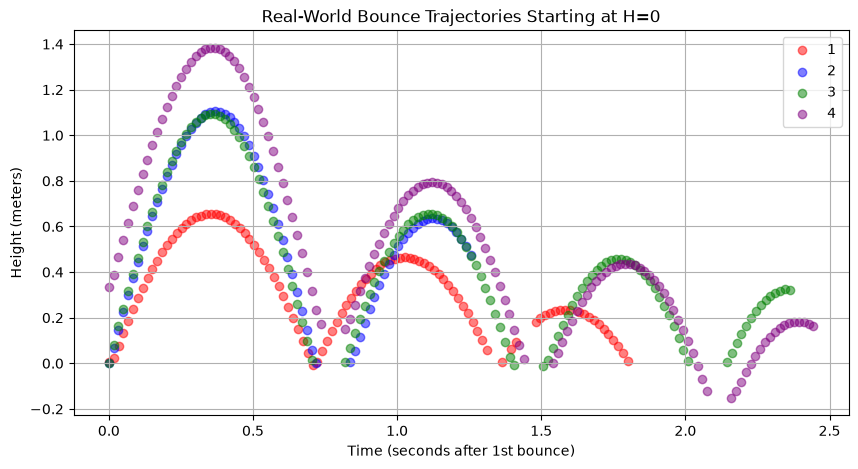

In [21]:
dd  = normalize_height(d)
dd2 = normalize_height(d2)
dd3 = normalize_height(d3)
dd4 = normalize_height(d4)


for dataset in [dd, dd2, dd3, dd4]:
    dataset['ym'] = dataset['height_final'] * scale
    dataset['xm'] = dataset['cx'] * scale

dd4 = dd4[dd4['time'] <= 2.7]

dd['time']  = dd['time']  - get_first_impact_time(dd)
dd2['time'] = dd2['time'] - get_first_impact_time(dd2)
dd3['time'] = dd3['time'] - get_first_impact_time(dd3)
dd4['time'] = dd4['time'] - get_first_impact_time(dd4)

dd  = dd[dd['time'] >= 0]
dd2 = dd2[dd2['time'] >= 0]
dd3 = dd3[dd3['time'] >= 0]
dd4 = dd4[dd4['time'] >= 0]

plt.figure(figsize=(10, 5))
plt.scatter(dd['time'],  dd['ym'],  color='red',    alpha=0.5, label='1')
plt.scatter(dd2['time'], dd2['ym'], color='blue',   alpha=0.5, label='2')
plt.scatter(dd3['time'], dd3['ym'], color='green',  alpha=0.5, label='3')
plt.scatter(dd4['time'], dd4['ym'], color='purple', alpha=0.5, label='4')

plt.xlabel('Time (seconds after 1st bounce)')
plt.ylabel('Height (meters)')  
plt.title('Real-World Bounce Trajectories Starting at H=0')
plt.legend()
plt.grid()
plt.show()

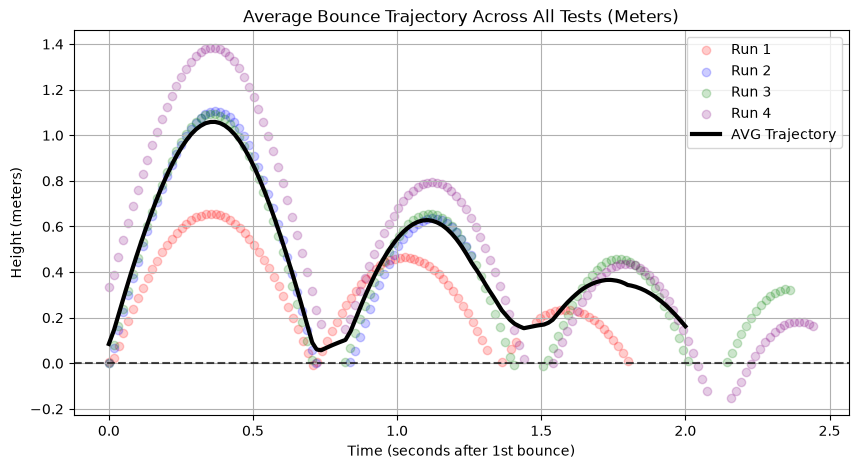

In [22]:
time_grid = np.linspace(0, 2.0, 1000)

h1 = np.interp(time_grid, dd['time'],  dd['ym'])
h2 = np.interp(time_grid, dd2['time'], dd2['ym'])
h3 = np.interp(time_grid, dd3['time'], dd3['ym'])
h4 = np.interp(time_grid, dd4['time'], dd4['ym'])
avg_heights = np.mean([h1, h2, h3, h4], axis=0)

x1 = np.interp(time_grid, dd['time'],  dd['xm'])
x2 = np.interp(time_grid, dd2['time'], dd2['xm'])
x3 = np.interp(time_grid, dd3['time'], dd3['xm'])
x4 = np.interp(time_grid, dd4['time'], dd4['xm'])
avg_x = np.mean([x1, x2, x3, x4], axis=0)

dd_avg = pd.DataFrame({'time': time_grid, 'xm': avg_x, 'ym': avg_heights})

plt.figure(figsize=(10, 5))
plt.scatter(dd['time'],  dd['ym'],  color='red',    alpha=0.2, label='Run 1')
plt.scatter(dd2['time'], dd2['ym'], color='blue',   alpha=0.2, label='Run 2')
plt.scatter(dd3['time'], dd3['ym'], color='green',  alpha=0.2, label='Run 3')
plt.scatter(dd4['time'], dd4['ym'], color='purple', alpha=0.2, label='Run 4')
plt.plot(dd_avg['time'], dd_avg['ym'], color='black', linewidth=3, label='AVG Trajectory')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Time (seconds after 1st bounce)')
plt.ylabel('Height (meters)')
plt.title('Average Bounce Trajectory Across All Tests (Meters)')
plt.legend()
plt.grid(True)
plt.show()